In [ ]:
# APL1_56_analysis.py
# copyright@pifuyuini
# 仅供实验小组成员杨舒云、戴鹏辉使用


In [2]:
# 寻峰算法
def AMPD(x, data):
    """
    实现AMPD算法  
    param x: x坐标数组，1-D numpy.ndarray  
    param data: y坐标数组，1-D numpy.ndarray  
    return: 峰值所在索引值的列表, 峰值对应的x坐标, 峰值对应的y坐标  

    参考https://zhuanlan.zhihu.com/p/549588865
    """
    
    p_data = np.zeros_like(data, dtype=np.int32)
    count = data.shape[0]
    arr_rowsum = []
    for k in range(1, count // 2 + 1):
        row_sum = 0
        for i in range(k, count - k):
            if data[i] > data[i - k] and data[i] > data[i + k]:
                row_sum -= 1
        arr_rowsum.append(row_sum)
    min_index = np.argmin(arr_rowsum)
    max_window_length = min_index
    for k in range(1, max_window_length + 1):
        for i in range(k, count - k):
            if data[i] > data[i - k] and data[i] > data[i + k]:
                p_data[i] += 1
                
    peaks_indices = np.where(p_data == max_window_length)[0]
    peak_x = np.take(x, peaks_indices)
    peak_y = np.take(data, peaks_indices)
    
    return peaks_indices, peak_x, peak_y

In [3]:
# gamma/Data1的数据

# 载入数据
g_data1 = np.loadtxt('gamma/Data1.txt')
g_channel_address1 = np.arange(len(g_data1))

# 滤波
window_length = 51  # 窗口长度，可以根据实际情况调整
polyorder = 3       # 多项式阶数，一般为2或3
smoothed_xg1 = savgol_filter(g_data1, window_length, polyorder)

In [4]:
# 主峰寻峰与计算半高宽
x = g_channel_address1
y = smoothed_xg1

# 找到主峰
peaks, _ = find_peaks(y)
peak_index = peaks[np.argmax(y[peaks])]  # 主峰索引
peak_x = x[peak_index]  # 主峰位置
peak_y = y[peak_index]  # 主峰值

# 半高宽计算* （注意它给出了一个处理离散实验数据的非拟合方案的标准半高宽计算流程）
half_max = peak_y / 2
left_idx = np.where(y[:peak_index] <= half_max)[0][-1]
right_idx = np.where(y[peak_index:] <= half_max)[0][0] + peak_index
# 线性插值计算左右边界的精确位置*
x_left = x[left_idx] + (half_max - y[left_idx]) / (y[left_idx + 1] - y[left_idx]) * (x[left_idx + 1] - x[left_idx])
x_right = x[right_idx] + (half_max - y[right_idx]) / (y[right_idx - 1] - y[right_idx]) * (x[right_idx - 1] - x[right_idx])
# 半高宽
fwhm = x_right - x_left

# 输出结果
print(f"主峰位置: {peak_x:.4f}")
print(f"主峰值: {peak_y:.4f}")
print(f"半高宽 (FWHM): {fwhm:.4f}")

主峰位置: 432.0000
主峰值: 1305.1620
半高宽 (FWHM): 47.2794


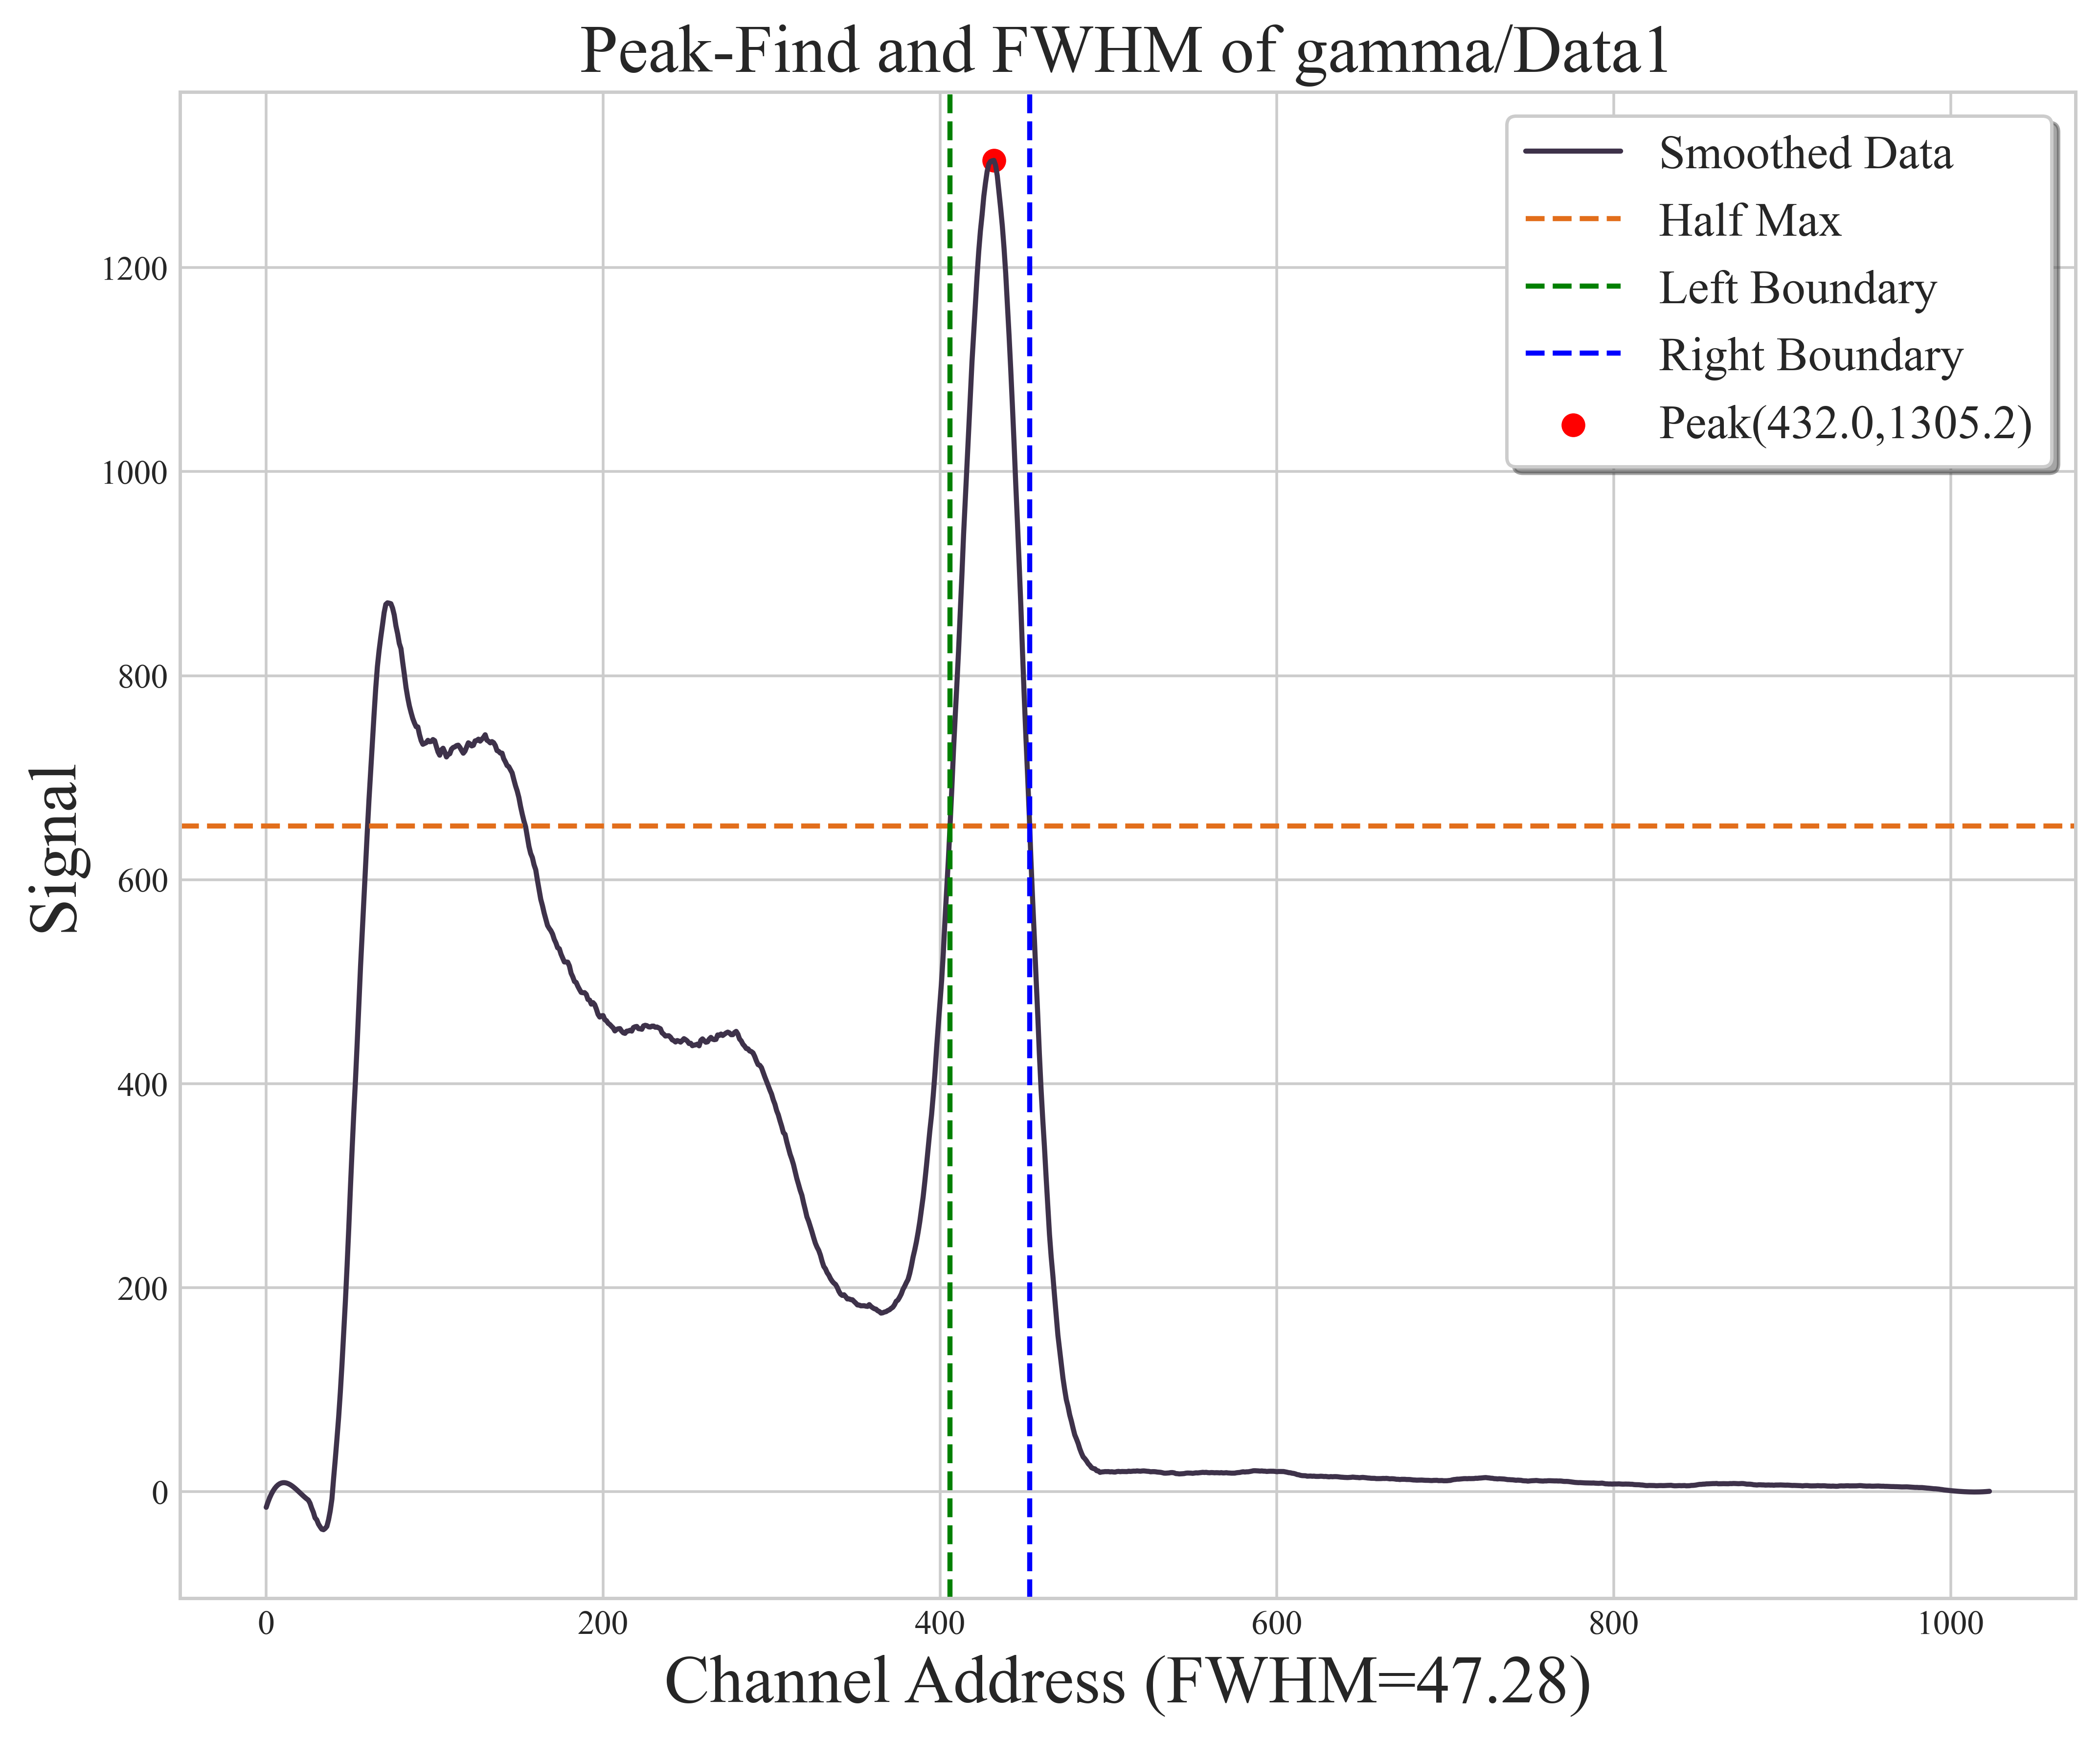

In [5]:
# 可视化
plt.figure()
plt.plot(x, y, label="Smoothed Data", color=colors[0])
plt.axhline(half_max, color=colors[3], linestyle="--", label="Half Max")
plt.axvline(x_left, color="g", linestyle="--", label="Left Boundary")
plt.axvline(x_right, color="b", linestyle="--", label="Right Boundary")
plt.scatter([peak_x], [peak_y], color="red", label=f"Peak({peak_x:.1f},{peak_y:.1f})")
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.title("Peak-Find and FWHM of gamma/Data1", fontsize=20)
plt.xlabel(f"Channel Address (FWHM={fwhm:.2f})")
plt.ylabel("Signal")
plt.show()

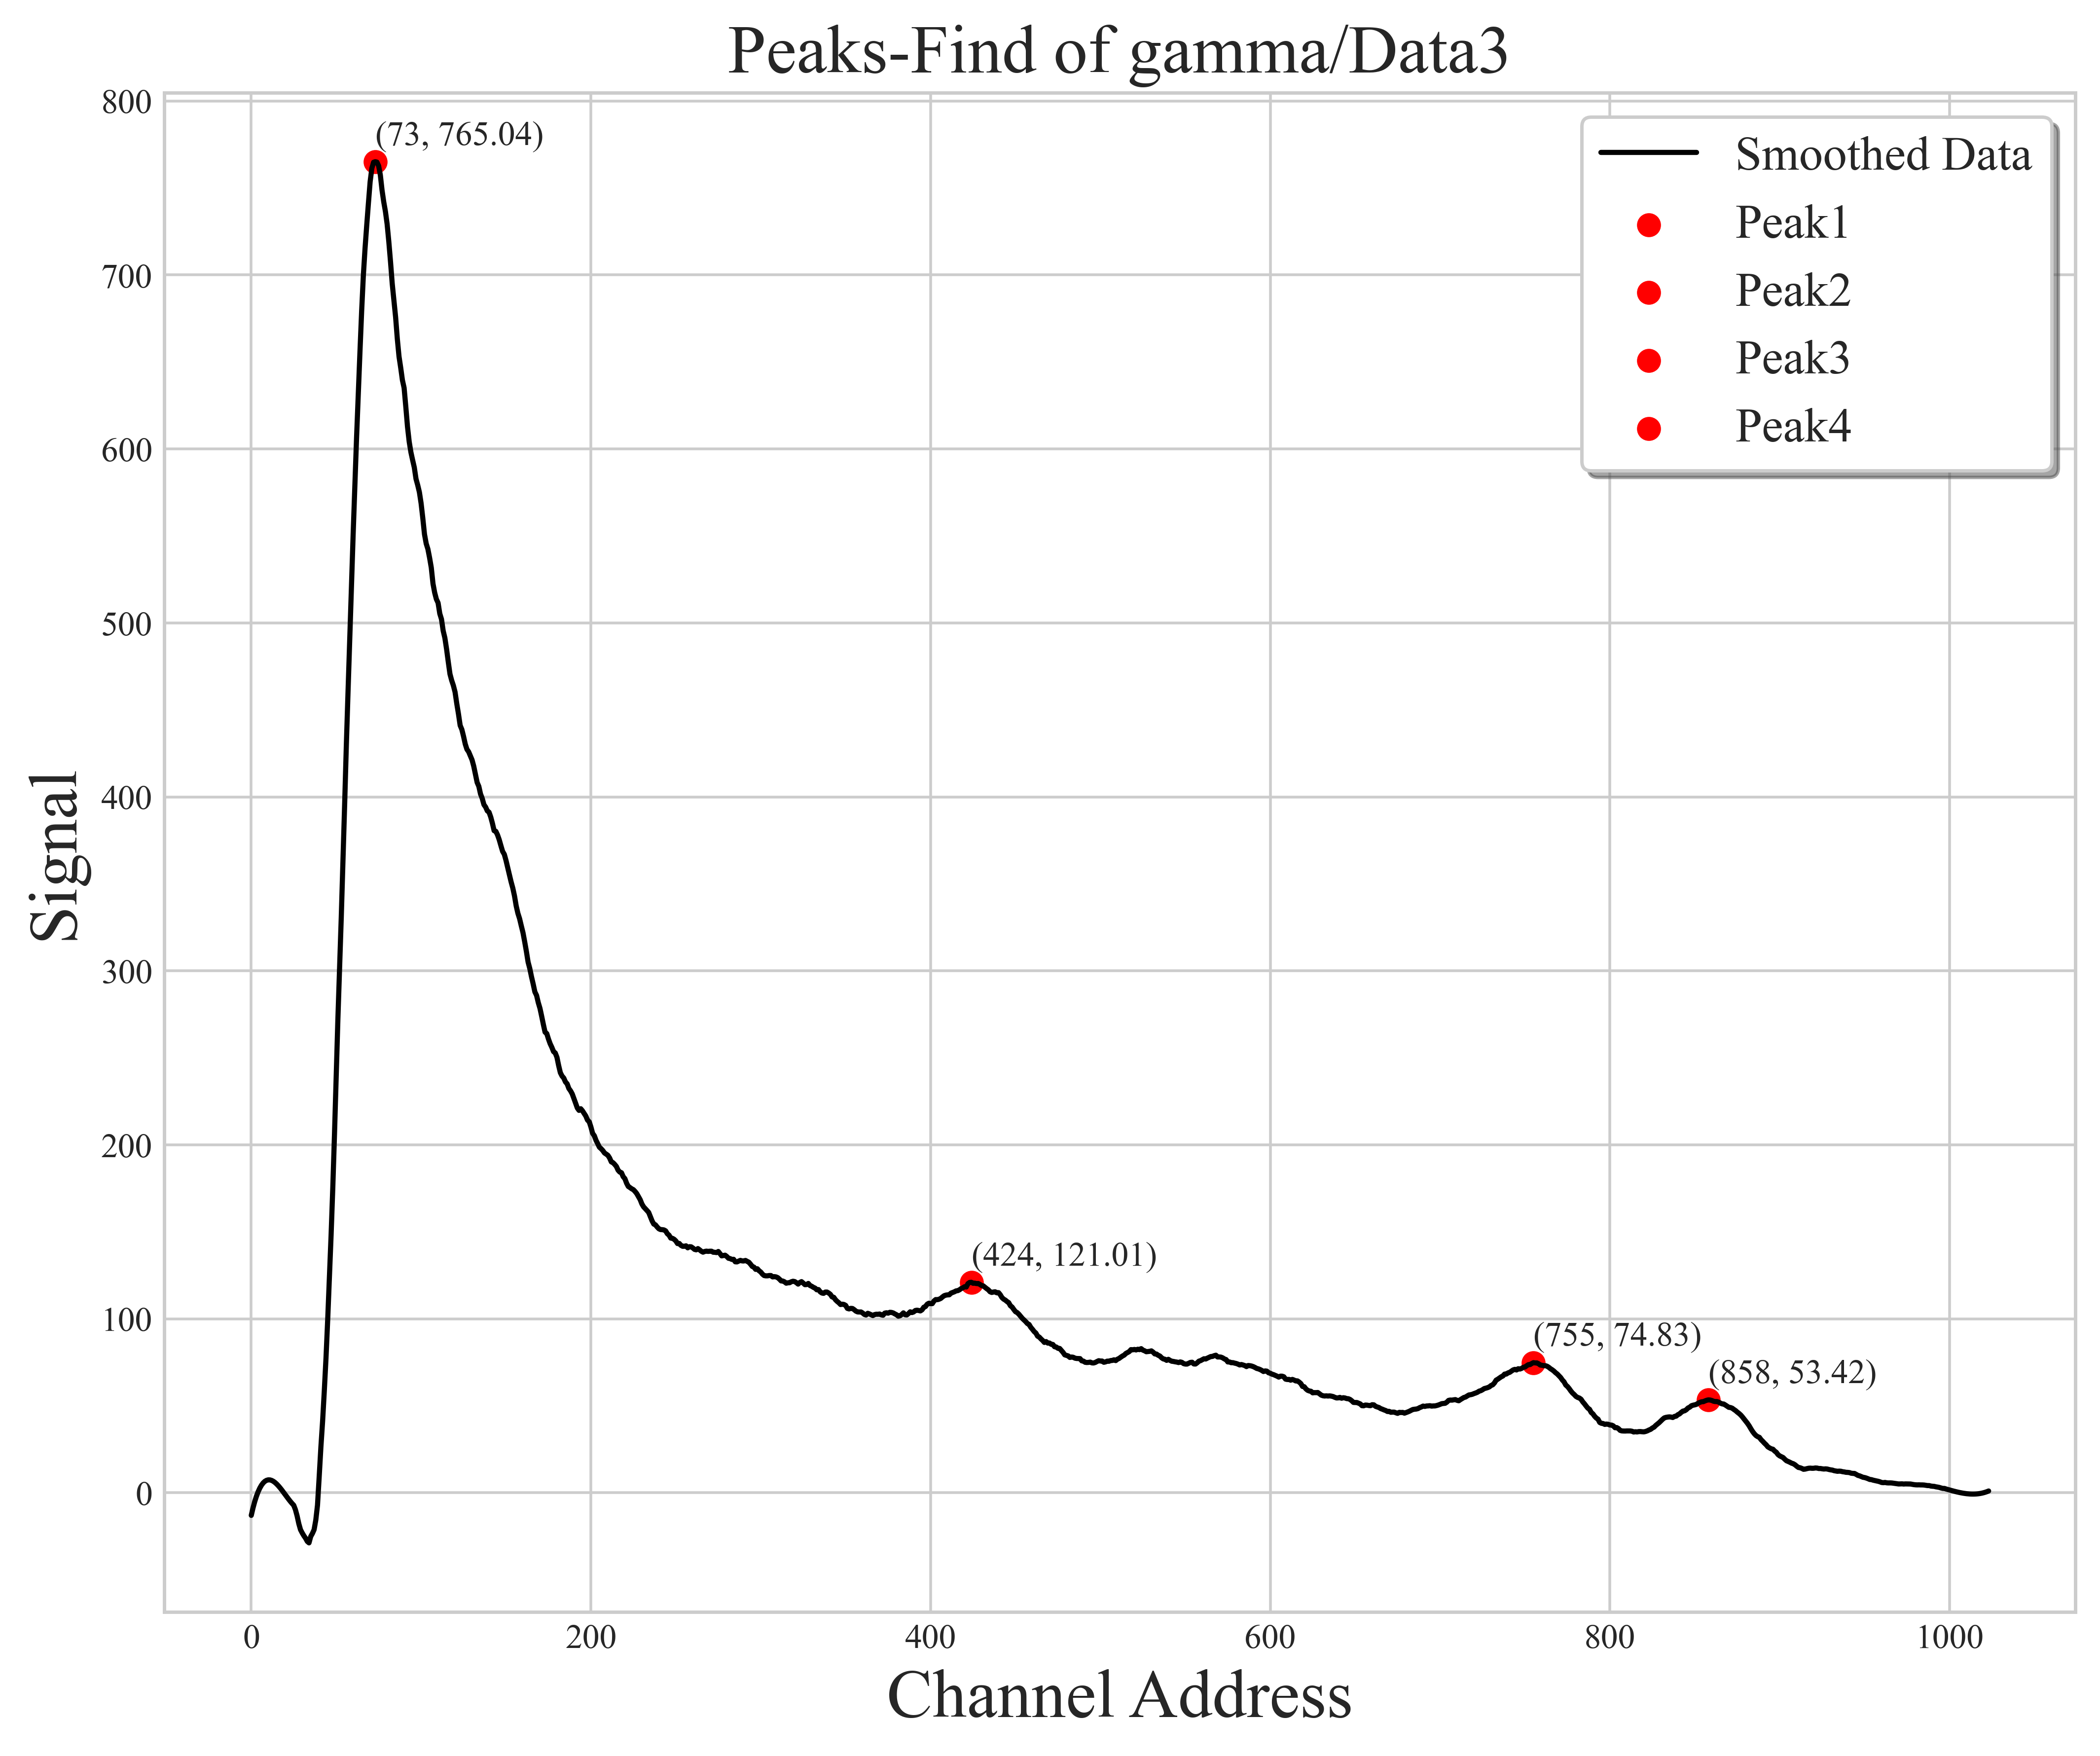

In [6]:
# 处理gamma/Data3的数据

# 加载数据
g_data3 = np.loadtxt('gamma/Data3.txt')
g_channel_address3 = np.arange(len(g_data3))

# 滤波
window_length = 51  # 窗口长度，可以根据实际情况调整
polyorder = 3       # 多项式阶数，一般为2或3
smoothed_x3 = savgol_filter(g_data3, window_length, polyorder)

# 找到峰值及其对应的坐标
x3 = g_channel_address3
y3 = smoothed_x3
peaks_indices3, peak_x3, peak_y3 = AMPD(x3, y3) 

# 绘制曲线
plt.figure()
plt.plot(x3, y3, label='Smoothed Data', color='black')
for i in range(len(peaks_indices3)):
    plt.scatter(peak_x3[i], peak_y3[i], color='red', marker='o', label='Peak'+str(i+1))
    plt.annotate('({}, {})'.format(round(peak_x3[i], 2), round(peak_y3[i], 2)), xy=(peak_x3[i], peak_y3[i]),
                 xytext=(0, 5), textcoords='offset points')  
plt.title('Peaks-Find of gamma/Data3', fontsize=20)
plt.xlabel('Channel Address')
plt.ylabel('Signal')
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.show()

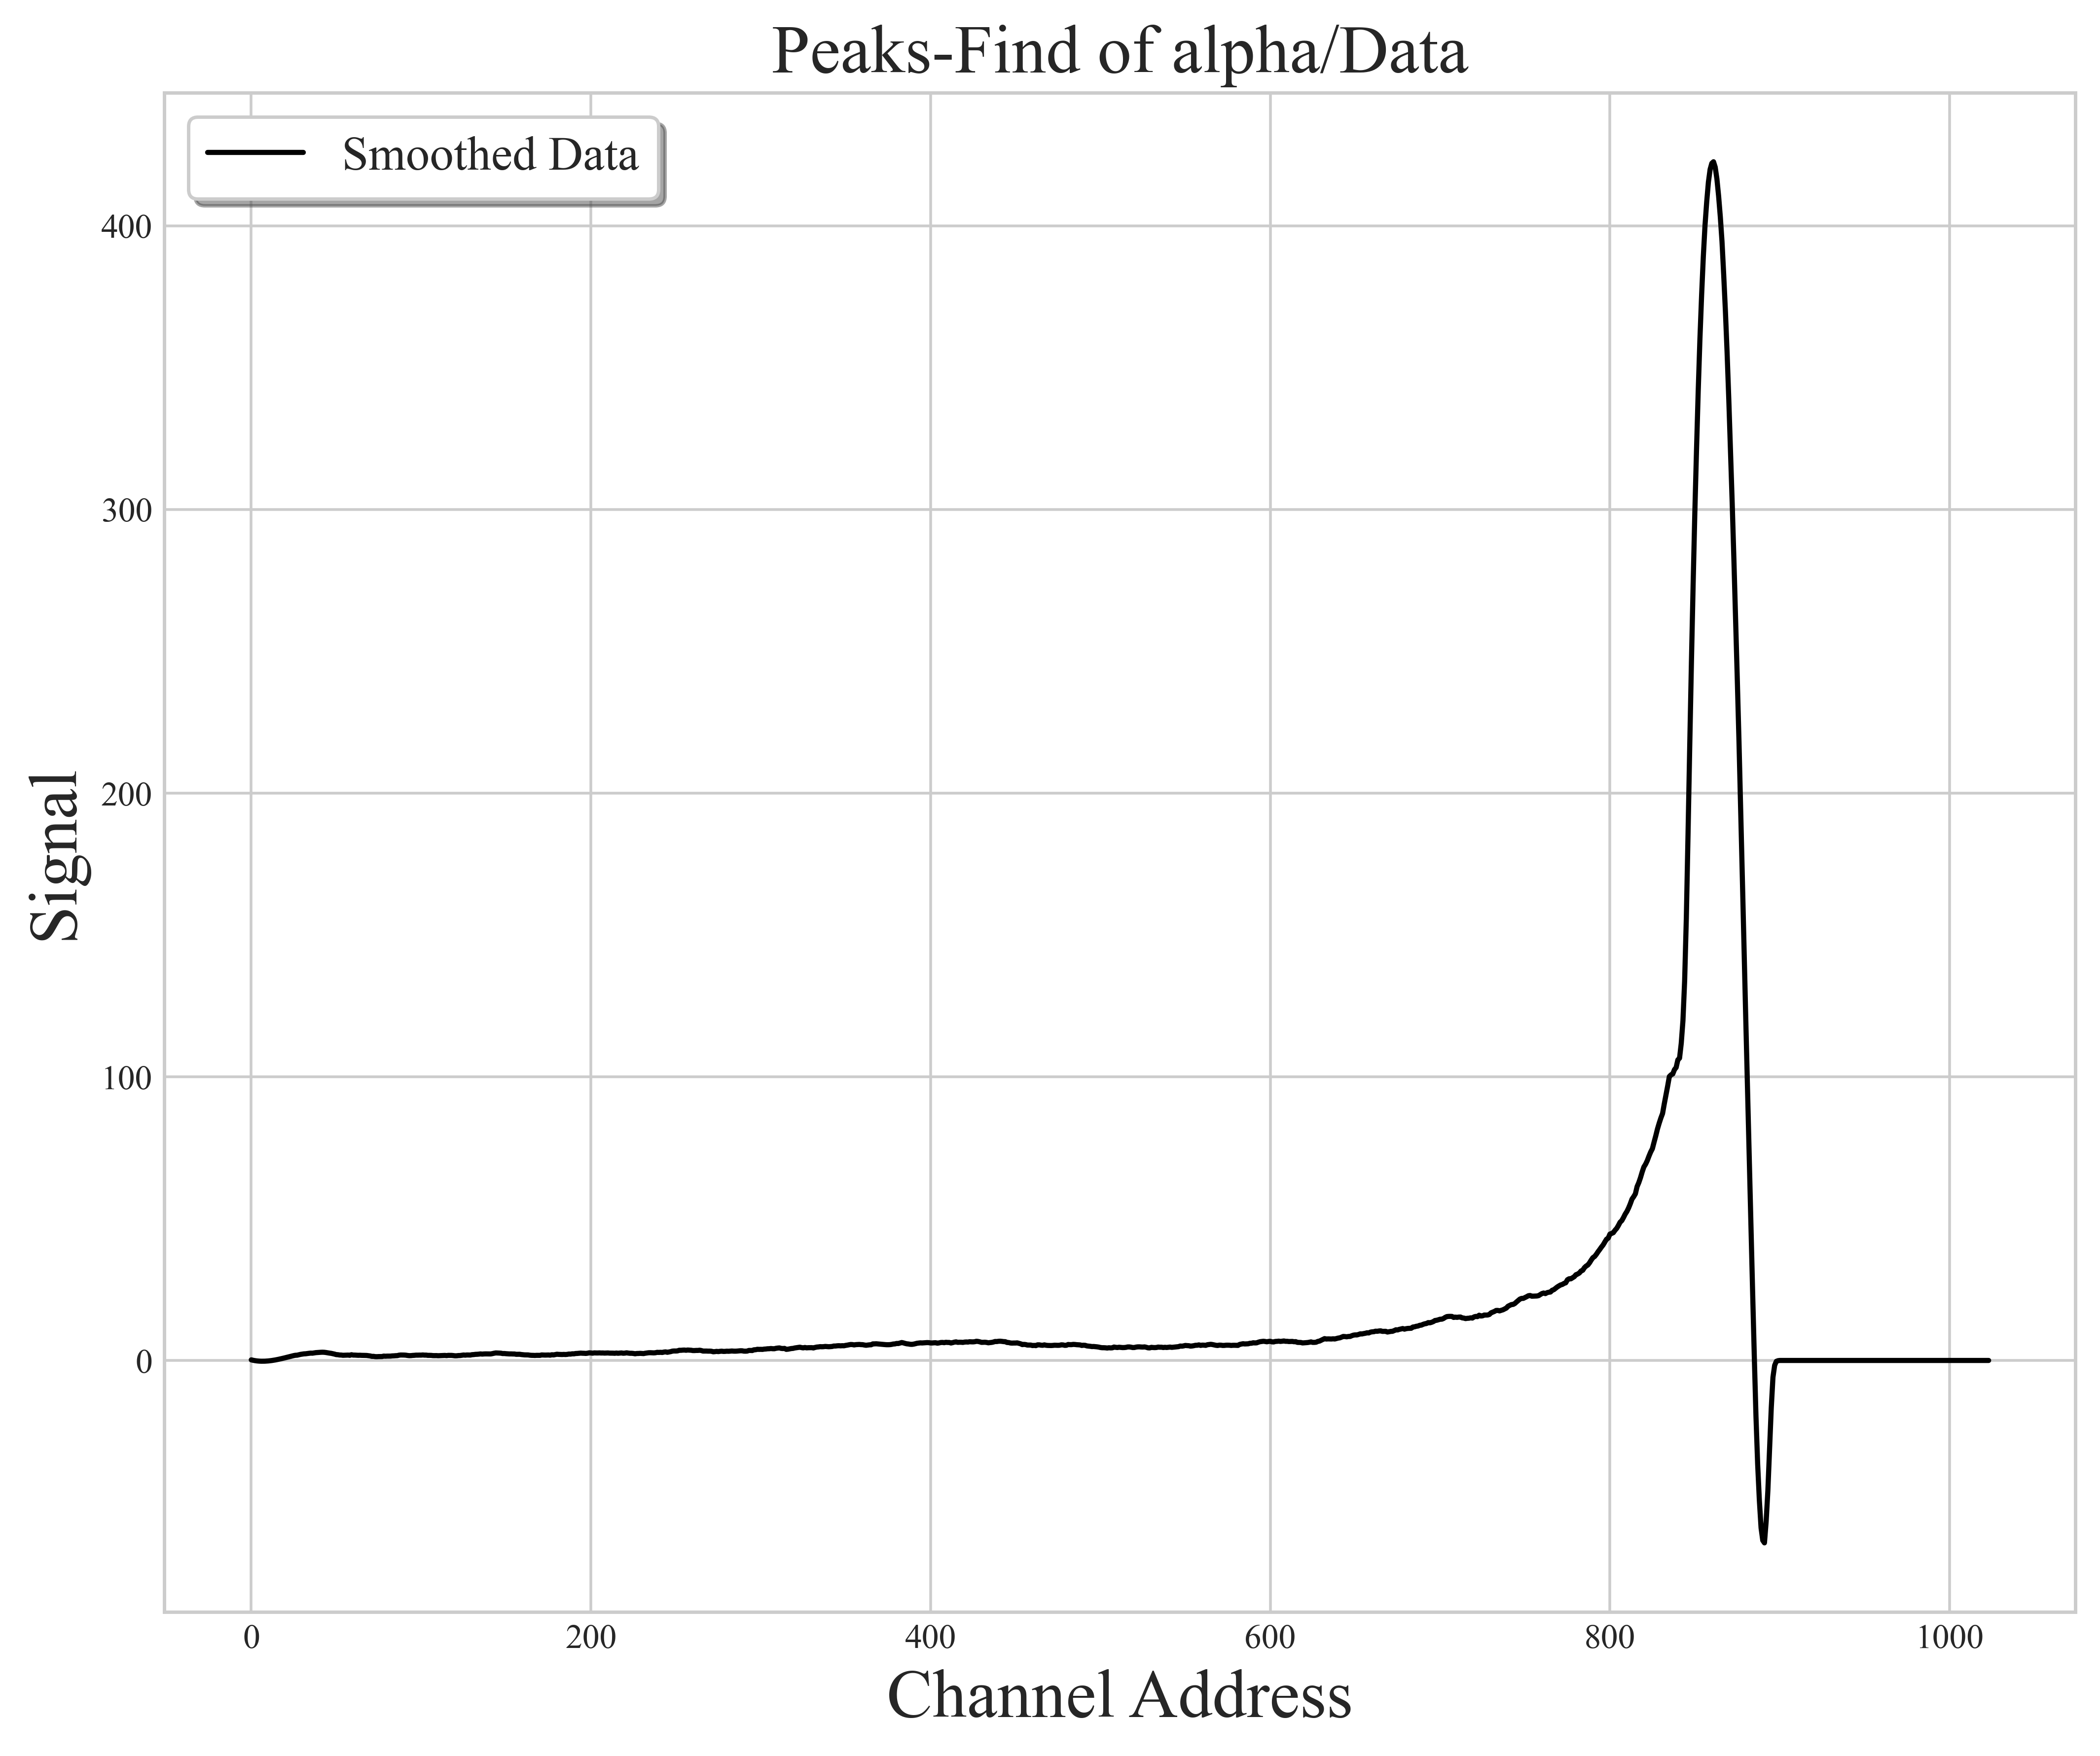

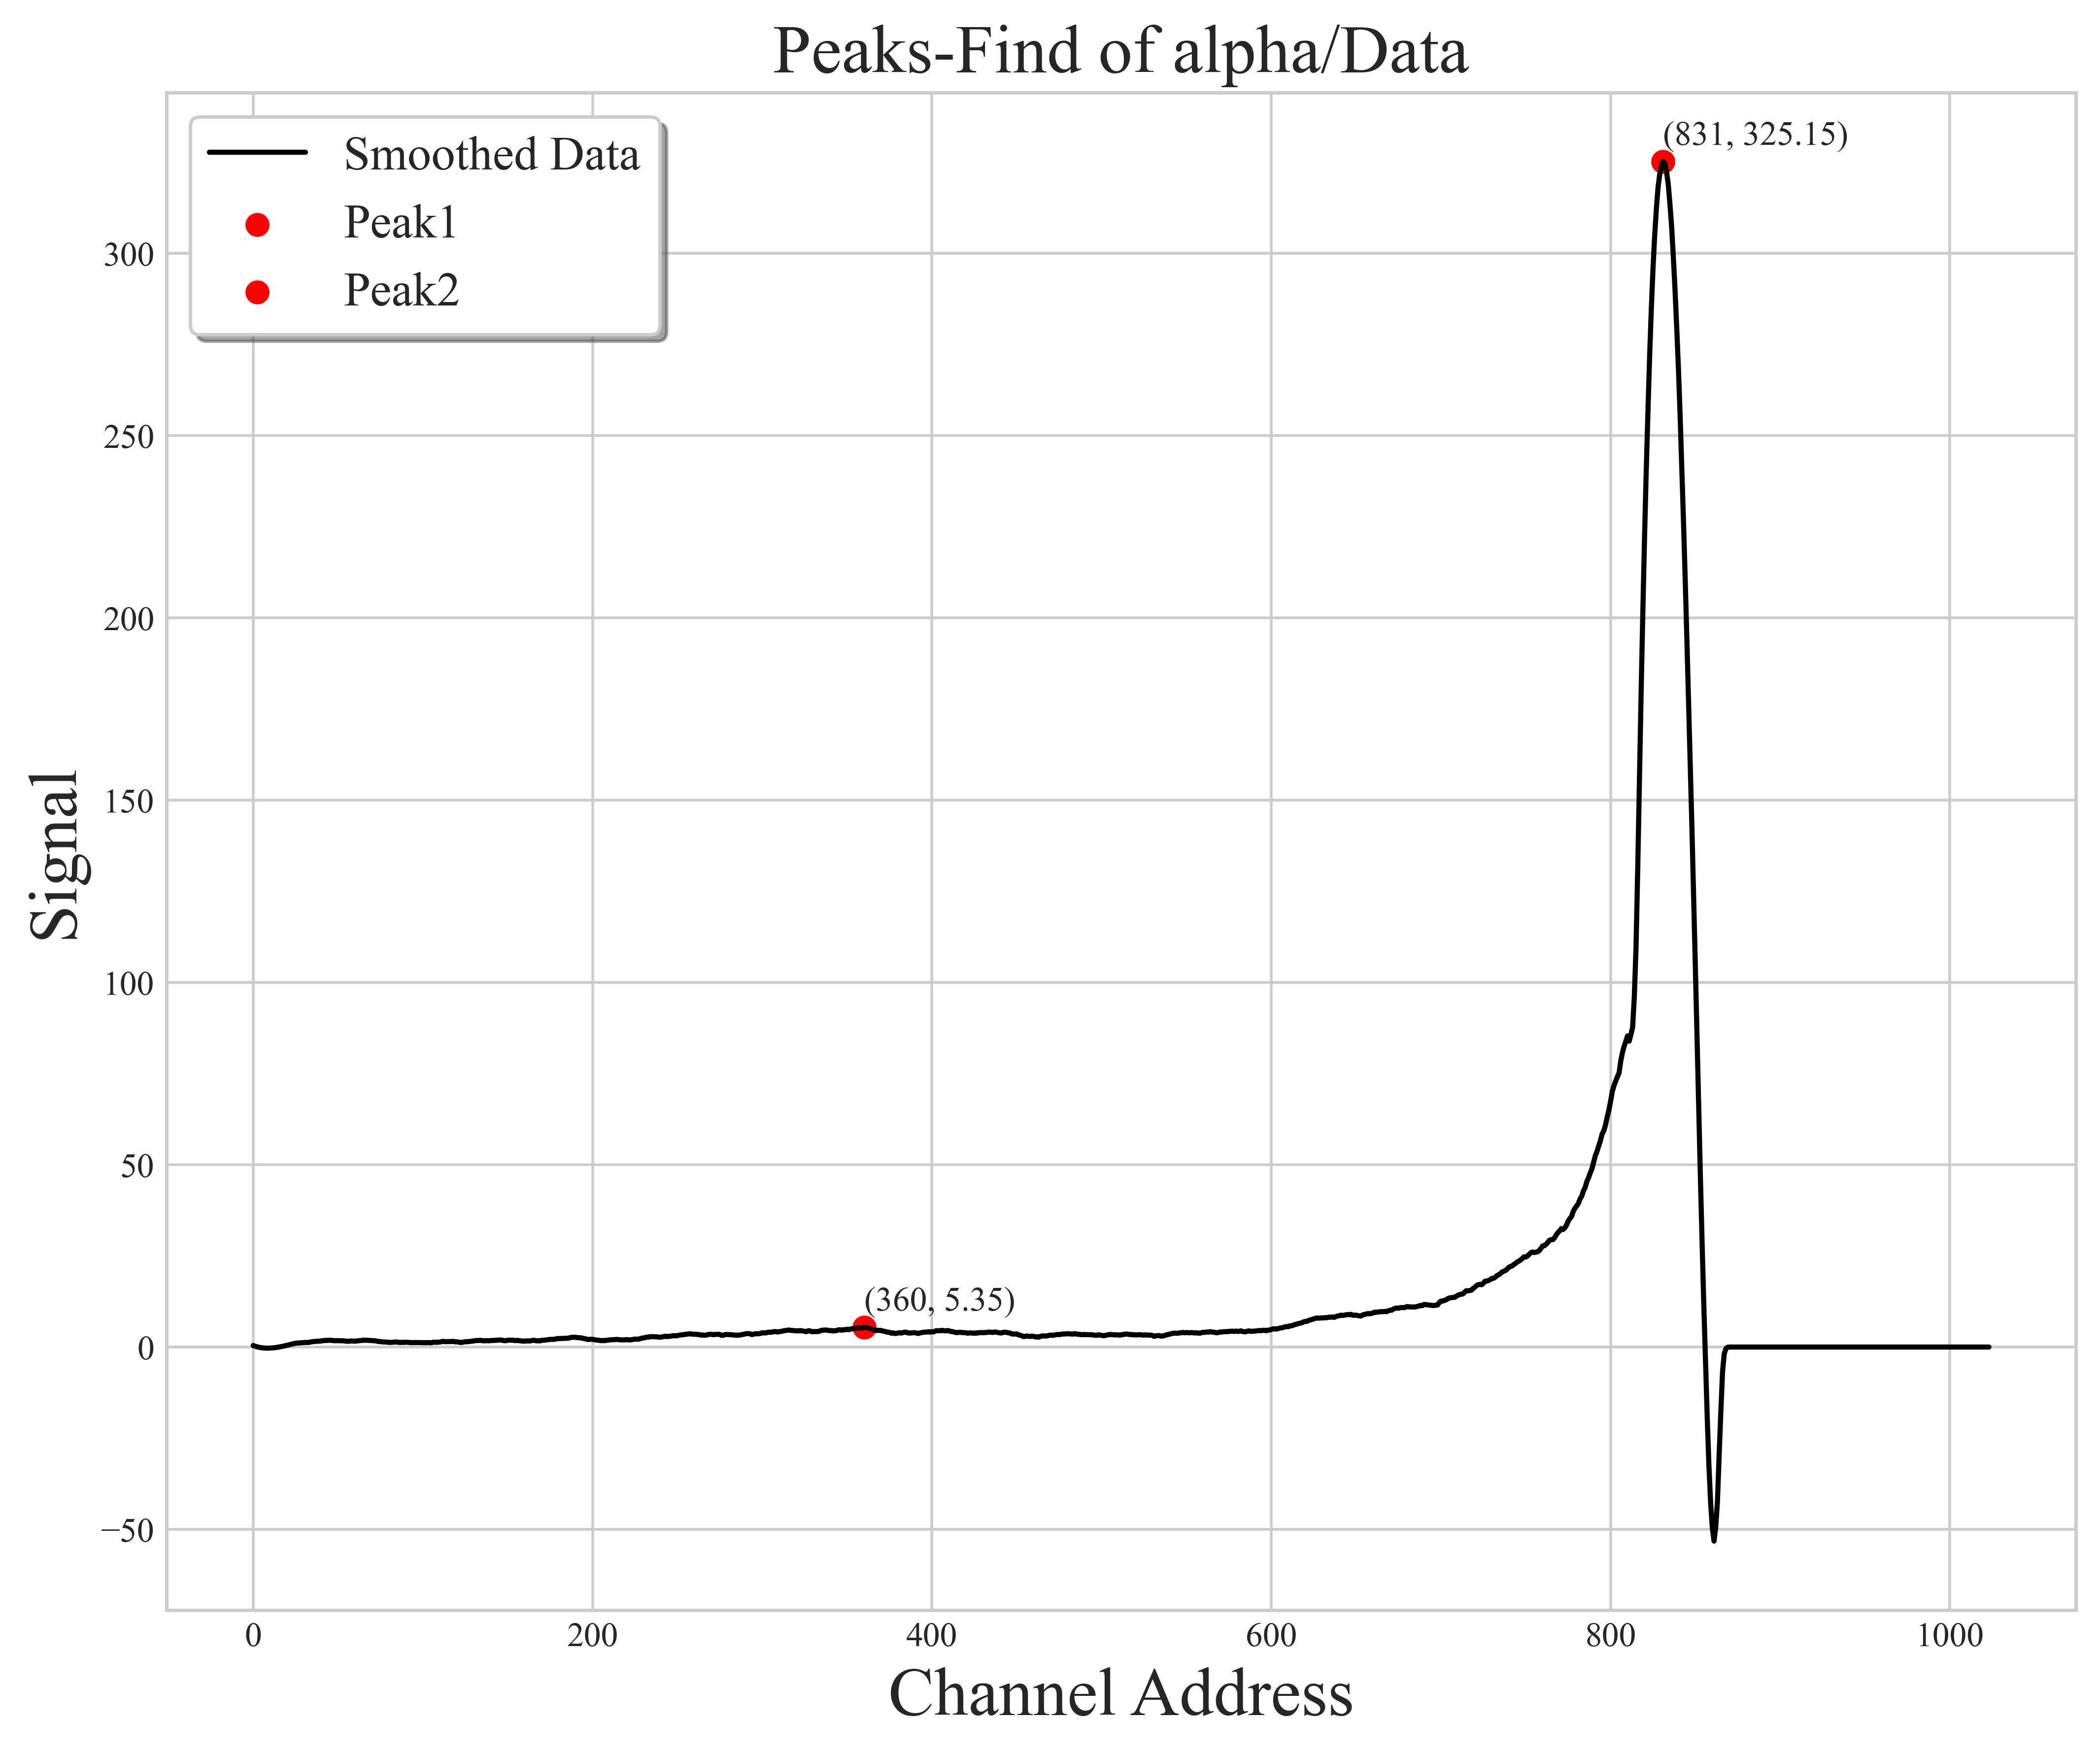

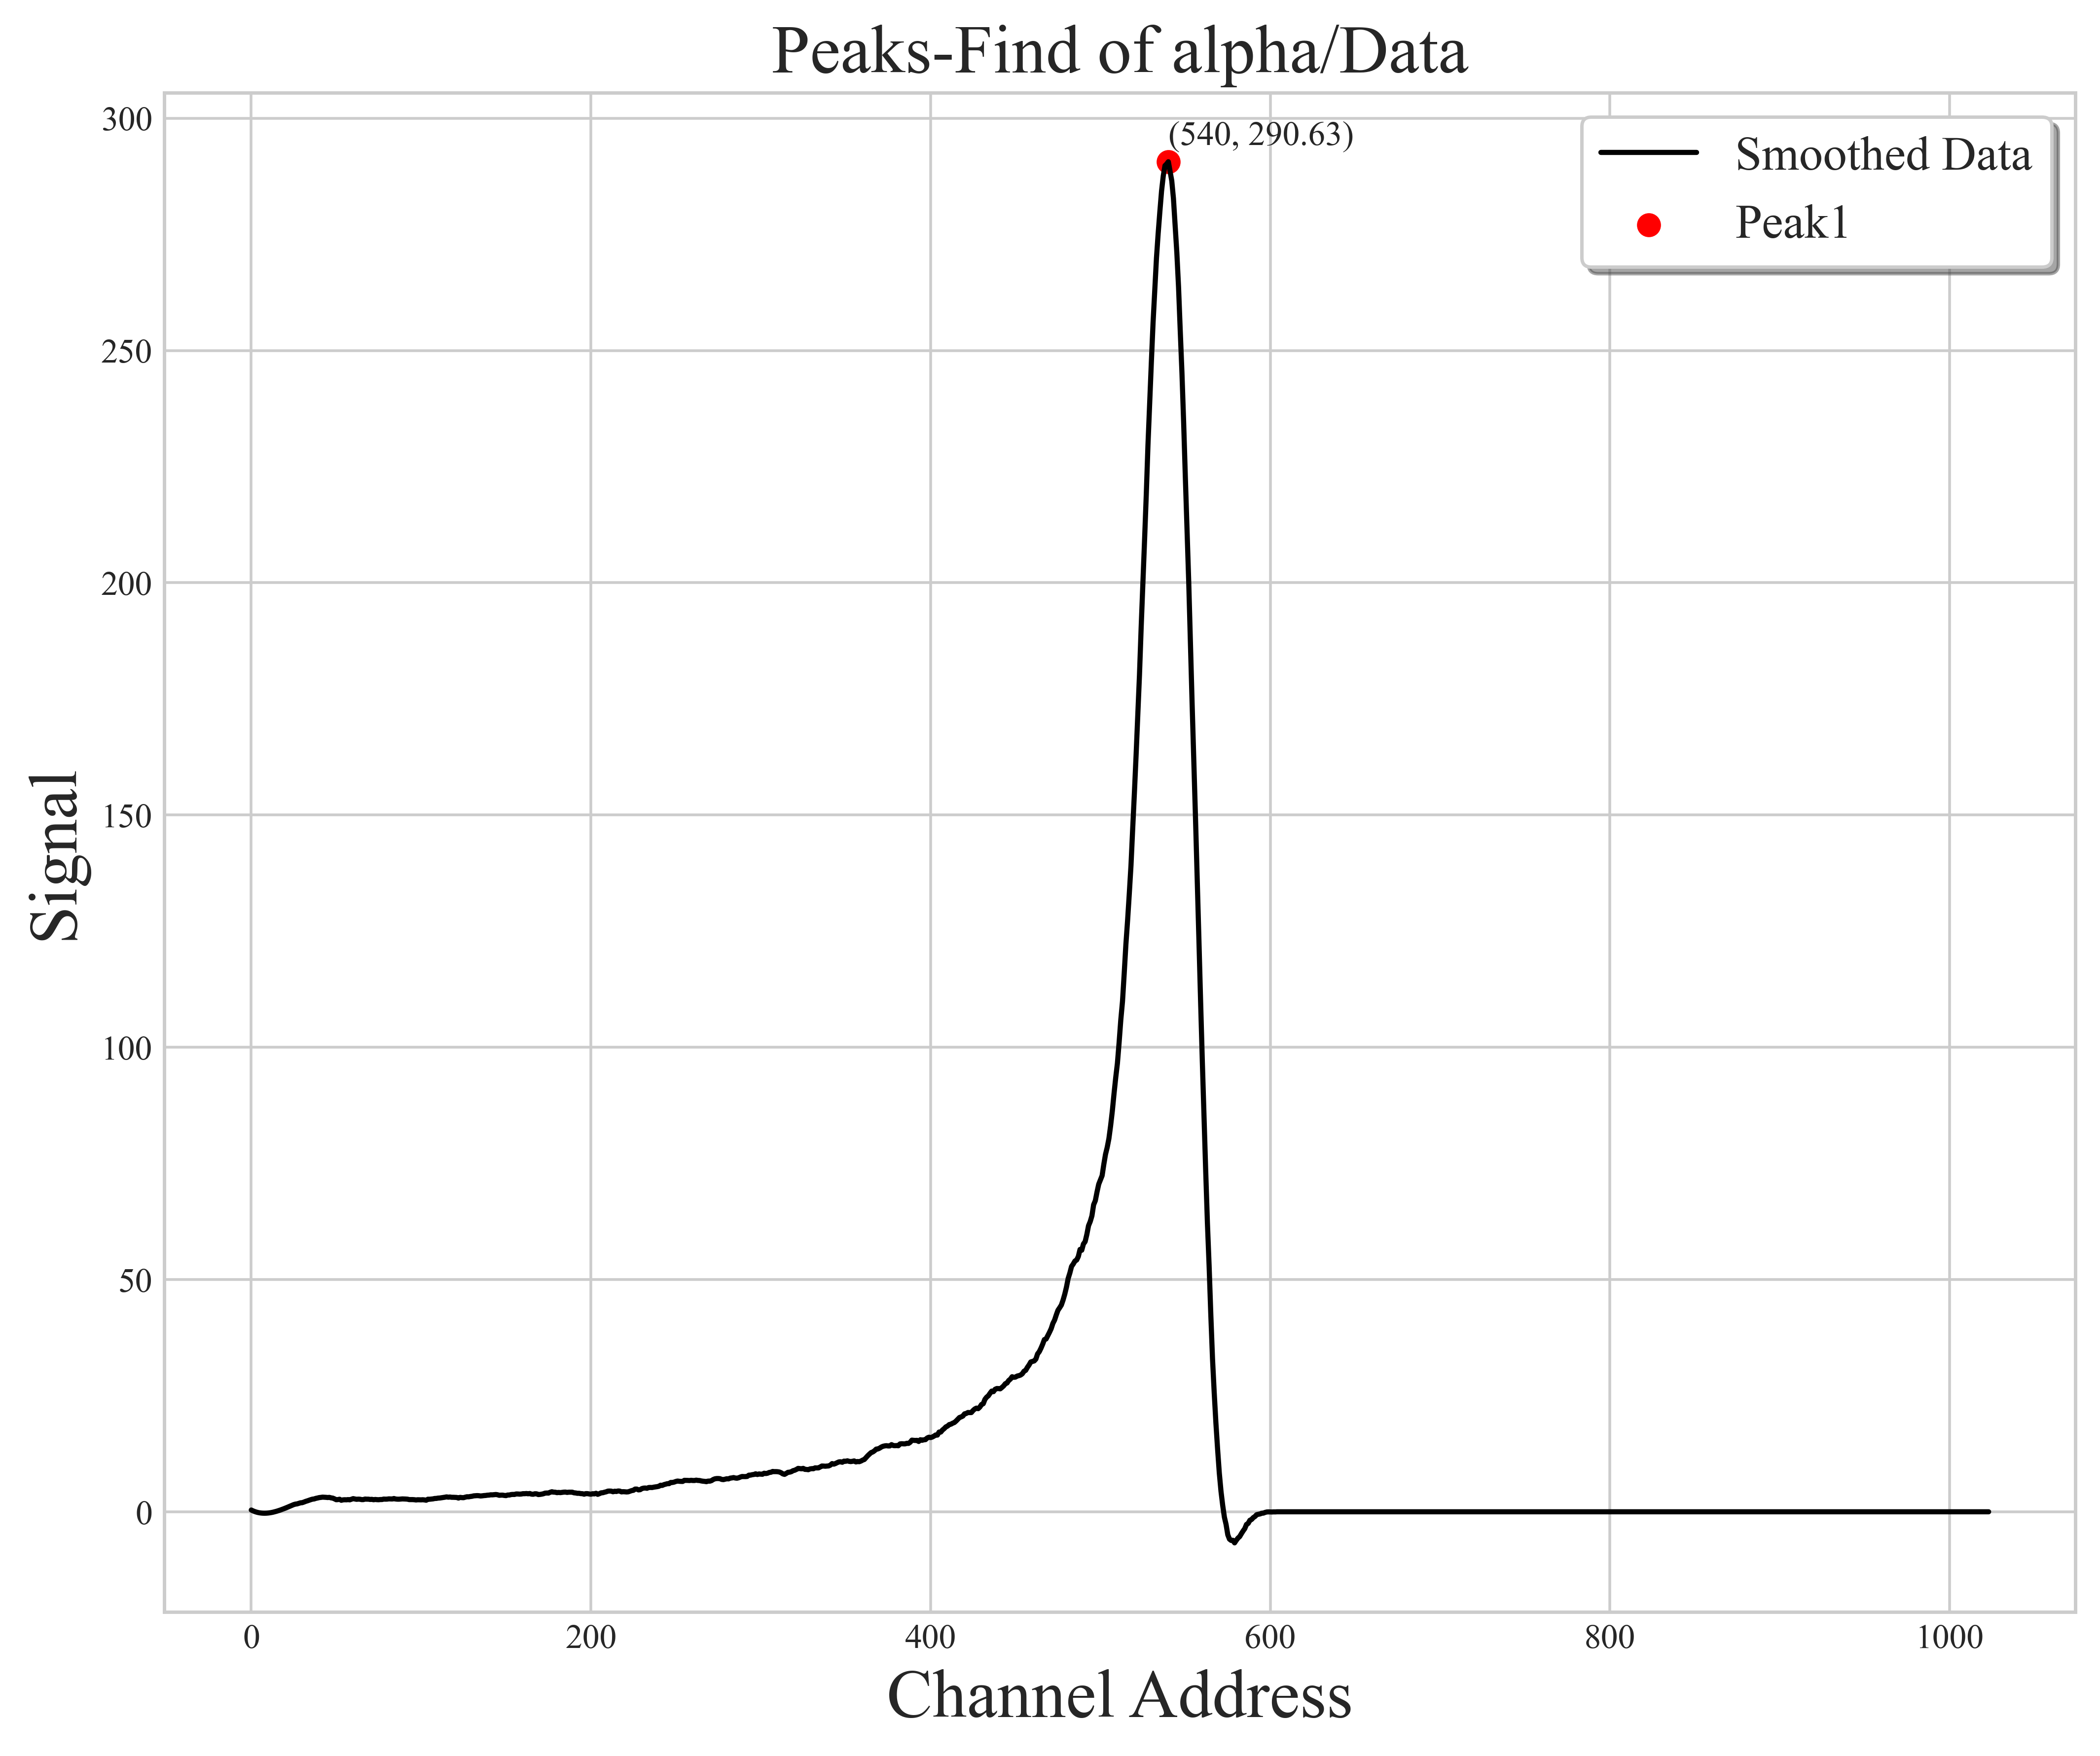

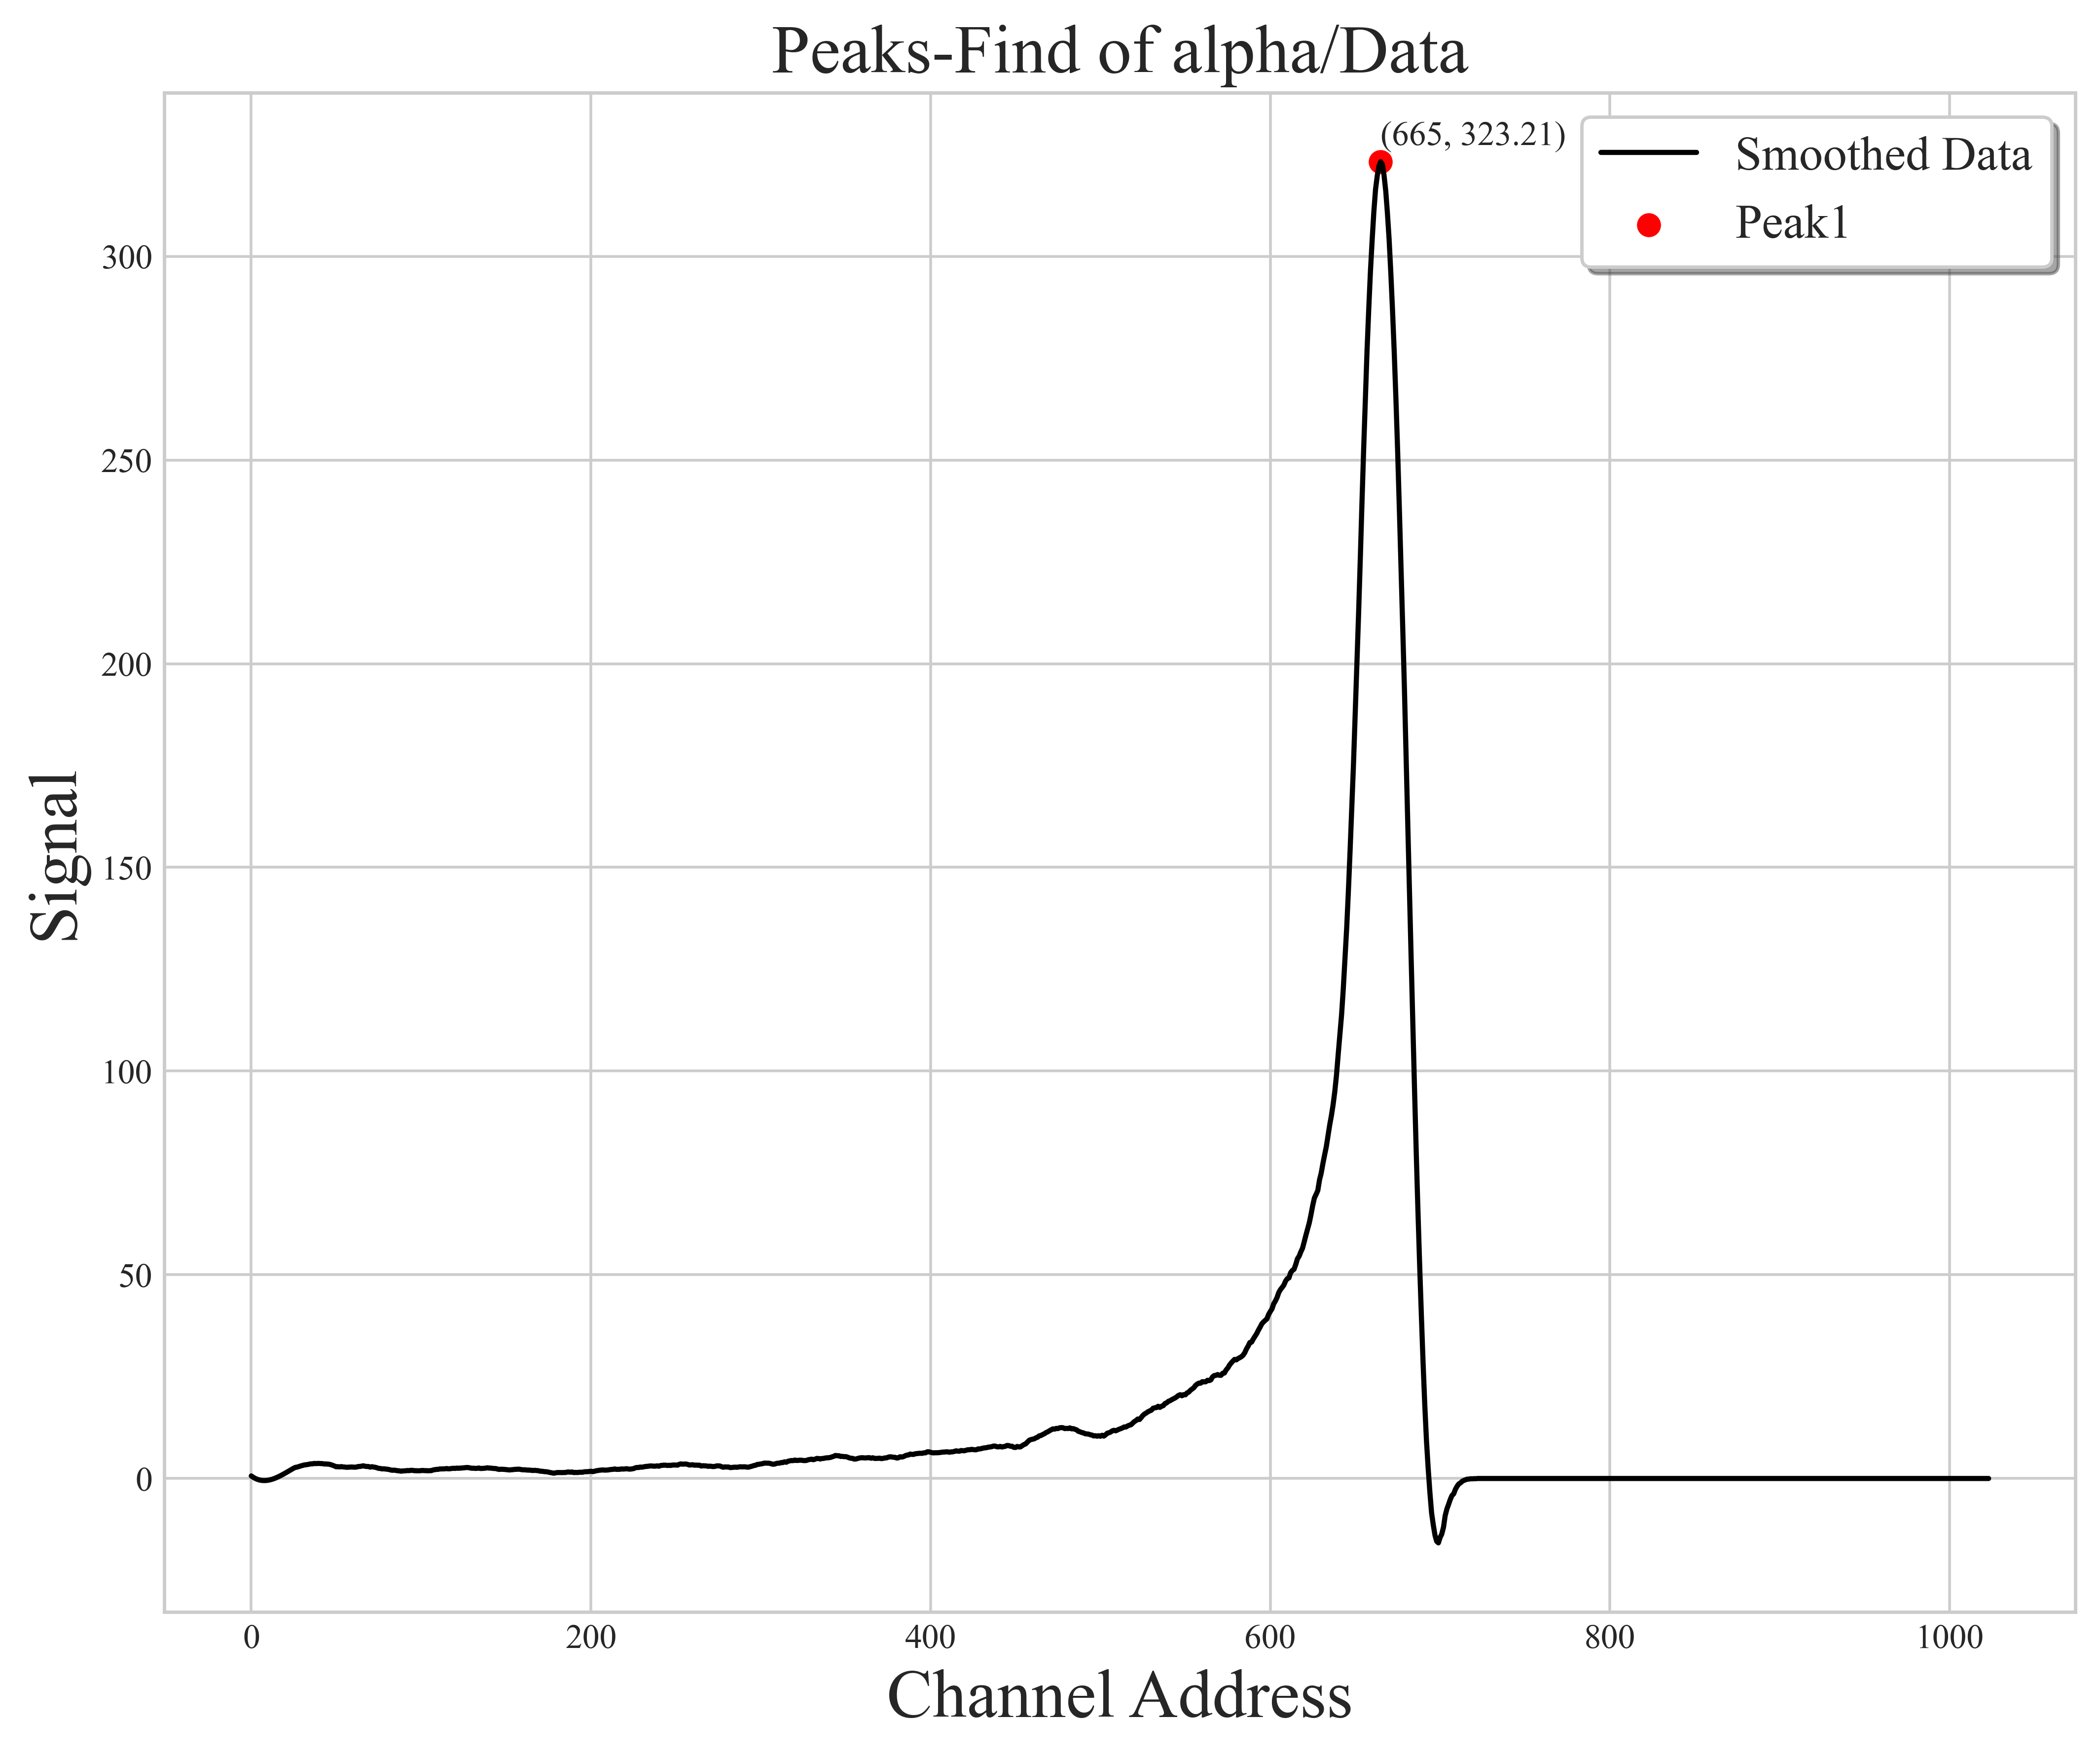

In [7]:
# 处理alpha的数据

# 批处理数据函数封装
def alpha_batch_processing(data):
    '''
    批处理函数封装  
    data: 1-D numpy.ndarray  
    return : None  
    输出图片
    '''
    channel_address = np.arange(len(data))
    window_length = 51  # 窗口长度，可以根据实际情况调整
    polyorder = 3       # 多项式阶数，一般为2或3
    smoothed_x = savgol_filter(data, window_length, polyorder)
    x = channel_address
    y = smoothed_x
    peaks_indices, peak_x, peak_y = AMPD(x, y) 
    plt.figure()
    plt.plot(x, y, label='Smoothed Data', color='black')
    for i in range(len(peaks_indices)):
        plt.scatter(peak_x[i], peak_y[i], color='red', marker='o', label='Peak'+str(i+1))
        plt.annotate('({}, {})'.format(round(peak_x[i], 2), round(peak_y[i], 2)), xy=(peak_x[i], peak_y[i]),
                    xytext=(0, 5), textcoords='offset points')  
    plt.title('Peaks-Find of alpha/Data', fontsize=20)
    plt.xlabel('Channel Address')
    plt.ylabel('Signal')
    plt.legend(fontsize=14, frameon=True, shadow=True)
    plt.show()
    return None

# 数据加载
a_data_set = []
for i in range(4):
    file_name = 'alpha/Data'+str(i+1)+'.txt'
    a_data_set.append(np.loadtxt(file_name))

for data in a_data_set:
    alpha_batch_processing(data)
